# 04｜RNN、LSTM、GRU 对比实验

本页只改变两个实验因素：循环单元和序列长度。数据规则、隐藏维度、优化器、学习率与随机种子保持一致。

**重要：**门控结构并不保证每次都赢。请先看结果，再写结论。为减少课堂小样本训练的随机失败，本项目把 LSTM 遗忘门偏置初始化为 1；其余权重沿用 PyTorch 默认初始化，这也属于模型实现的一部分。

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import torch

LAB_DIR = Path.cwd()
if not (LAB_DIR / "rnn_lab").is_dir():
    LAB_DIR = (LAB_DIR / "03_rnn_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

# 共享服务器约定：每个 Notebook 只占用一个 CPU 计算线程。
torch.set_num_threads(1)

from rnn_lab import ExperimentConfig, compare_cells, plot_comparison, print_result_table

## 课堂快速模式

`FAST_MODE=True` 运行 2 个长度 × 3 种模型。完整模式增加长度 60，应由课堂统一分批启动，避免约 50 个账号同时进行九组训练。

模型          长度       准确率       参数量      时间/秒
--------------------------------------------
RNN         12    100.0%       843      0.38
LSTM        12    100.0%     3,147      0.44
GRU         12    100.0%     2,379      0.67
RNN         30    100.0%       843      0.57
LSTM        30     66.7%     3,147      0.56
GRU         30    100.0%     2,379      1.32


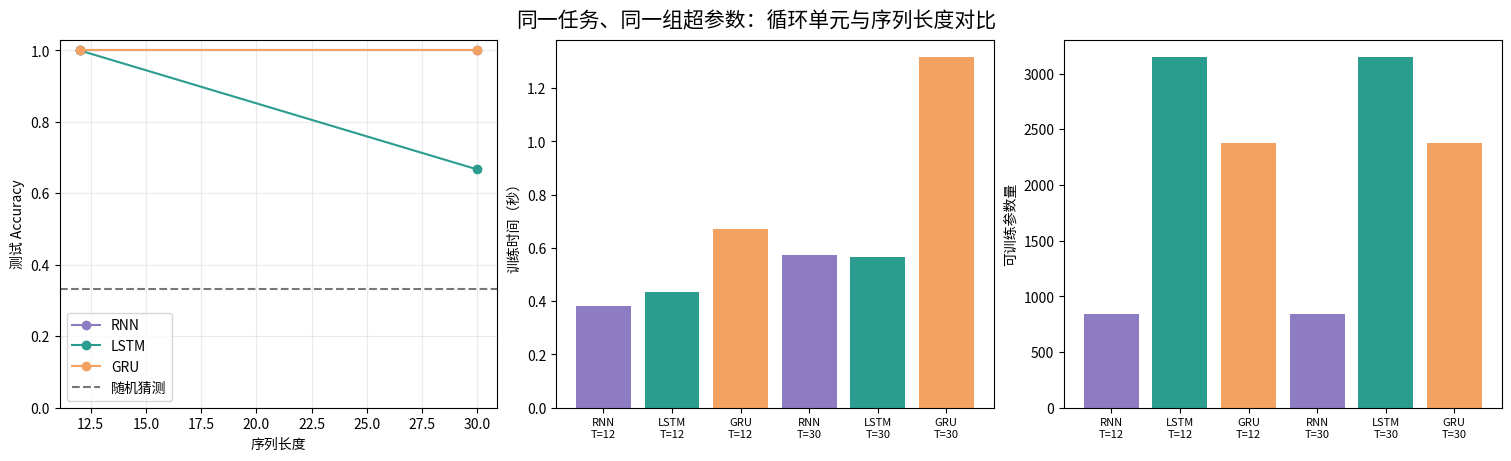

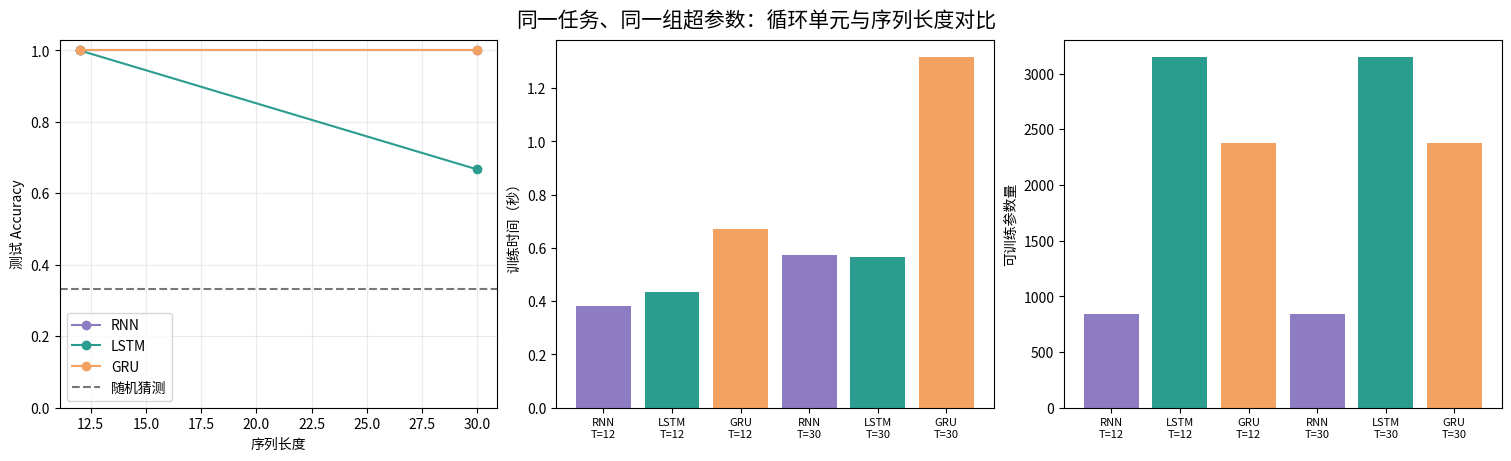

In [2]:
FAST_MODE = True
DEVICE = "cpu"
# 使用 GPU 时必须写成 "cuda:x"，x 为课堂分配的编号。

lengths = (12, 30) if FAST_MODE else (12, 30, 60)
base = ExperimentConfig(
    hidden_size=24,
    epochs=30 if FAST_MODE else 40,
    train_size=600,
    val_size=180,
    test_size=180,
    batch_size=64,
    learning_rate=0.003,
    seed=42,
    device=DEVICE,
)
results = compare_cells(base, lengths=lengths)
print_result_table(results)
plot_comparison(results)

## 如何写实验结论

请同时回答：

1. 哪些条件保持不变？
2. 哪个模型在哪个长度表现较好？
3. 参数量和时间付出了什么代价？
4. 结果是否在不同随机种子下仍然出现？

同隐藏维度不等于同参数量，因此不能把这张图解释为严格的“容量完全公平比较”。

In [3]:
# 可选复核：只改变随机种子，再看结论是否稳定。
# 将下面改为 True 才运行；课堂默认不重复六组训练。
RUN_SEED_CHECK = False
if RUN_SEED_CHECK:
    from dataclasses import replace
    second_results = compare_cells(replace(base, seed=7), lengths=lengths)
    print_result_table(second_results)
    plot_comparison(second_results)
else:
    print("未运行随机种子复核。需要时把 RUN_SEED_CHECK 改为 True。")

未运行随机种子复核。需要时把 RUN_SEED_CHECK 改为 True。


## 完成本页后：释放资源并结束内核

运行下面最后一个单元格会清空变量、关闭图片、释放未使用的 CUDA 缓存，并向 Jupyter 内核发送正常关机请求。

运行后 VS Code 显示“内核已停止”或要求重新选择内核属于正常现象。再次实验时重新选择课程内核即可。

In [ ]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("清理完成，正在结束当前 Notebook 的 Python 内核……")
get_ipython().kernel.do_shutdown(restart=False)